<div style="border: 5px solid purple; padding: 15px; margin: 5px">
<b> Reviewer's comment</b>
    
Hi Aldo, my name is Svetlana (https://hub.tripleten.com/u/6dee602c). Congratulations on submitting Time Series project! 🎉 Here I will be using the standard color marking:
    

<div style="border: 5px solid green; padding: 15px; margin: 5px">

Great solutions and ideas that can and should be used in the future are in green comments. Some of them are: 
    
    
- You have successfully prepared the subsets. It is important to split the data correctly in order to ensure there's no intersection;    
    
    
- It's great that you used `statsmodels` to analyze time series as it provides comprehensive summaries that can be useful when we need to make data-driven decisions;



- Trained a model;

- Wrote an excellent conclusion! A well-written conclusion shows how the project met its objectives and provides a concise and understandable summary for those who may not have been involved in the details of the project. Good job! 

</div>
    
<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>

Yellow color indicates what should be optimized. This is not necessary, but it will be great if you make changes to this project. I've left several recommendations throughout the project. 
    
</div>
<div style="border: 5px solid red; padding: 15px; margin: 5px">
<b> Reviewer's comment </b>

Issues that must be corrected to achieve accurate results are indicated in red comments. Please note that the project cannot be accepted until these issues are resolved. More specifically:
    
    
- Please add conclusions in the EDA section. Without conclusions, it may be hard to a reader to understand the charts.


    
- Please shift the data before calculating the statistical features.
    
    

- Consider using at least one more algorithm to train additional model(s). It can be Linear Regression, Decision Tree, or SARIMAX.
    

    
    
- Please try to meet the main requirement of this poject: the best model muct achieve RMSE of no more than 48 on the final test.  
    
</div>         
<hr>
    
<font color='dodgerblue'>**To sum up:**</font> thank you very much for submitting the project! You did a fantastic job here. You have successfully trained several models and analyzed time series, which is great! The results are represented and interpreted effectively. However, there're a couple of issues that need your attention. Would you take a look at my comments?
    

<hr>
    
Please use some color other than those listed to highlight answers to my comments.
I would also ask you **not to change, move or delete my comments** to make it easier for me to navigate during the next review.



<hr> 
    
✍️ Some notes: 


- Here's a [link](https://machinelearningmastery.com/autoregression-models-time-series-forecasting-python/) to the article about the autoregression models that you may find interesting. 
    
    
- [Here](https://medium.com/@soumyachess1496/cross-validation-in-time-series-566ae4981ce4) you can read about cross-validation with time series.
    

- Consider using advanced tools such as [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) and [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html). `ColumnTransformer` and `Pipeline` are essential tools that help us create robust, maintainable, and efficient machine learning workflows. They work with data much more effectively. You can handle different data types and it is much easier to avoid data leakage. The code organization is very clean, but it may seem a bit difficult at the beginning. Take a look at this page to learn how to [organize a pipeline with ColumnTransformer](https://scikit-learn.org/stable/auto_examples/compose/plot_column_transformer_mixed_types.html).  
<hr>
    
📌 Please feel free to schedule a 1:1 sessions with our TAs [here](https://calendly.com/tripleten-ds-experts-team), join daily coworking sessions, or ask questions on TripleTen Hub if you need assistance 😉 
</div>

# Project 13 - Sweet Lift Taxi

# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

## Step 1 - Preparation

**"Step 1 - Preparation: Summary:**

The goal of this step is to load the data from the `/datasets/taxi.csv`  file, ensuring the datetime index is correctly formatted and in chronological order. The time series is then resampled to an hourly interval, as specified in the project instructions.

### Task 1 - Initialization:

In [1]:
import pandas as pd
import numpy as np

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

**"Task 1 - Initialization" Summary**:

This task imports the tools essential to complete this project, including the `pandas` library.

### Task 2 - Data loading:

In [2]:
# Loading data and set datetime index
data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

**"Task 2 - Data loading" Summary:**

This task uses `pd.read_csv()` to load the data. It specifies `index_col=[0]` to use the first column as the index and `parse_dates=[0]` to convert it to a datetime format.

### Task 3 - Data resampling:

In [3]:
# Verifing chronological order
print("Is index monotonic?", data.index.is_monotonic)

# Resampling to one-hour intervals
data = data.resample('1H').sum()

Is index monotonic? True


<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
The resampling is correct! We indeed need to use `sum`, not `mean`, since we need to forecast the total number of rides. 
    
</div>

**"Task 3 - Data resampling" Summary:**

The purpose of this task is twofold:

- It verifies that the index is monotonic (in chronological order) by using `data.index.is_monotonic`.

- It resamples the data to an hourly frequency by using `data.resample('1H').sum()` to aggregate the number of orders per hour.

## Step 2 - Analysis

**"Step 2 - Analysis" Summary:**

This step involves analyzing the resampled time series to identify patterns such as trends and seasonality. This helps in understanding the data's characteristics, which is crucial for effective feature engineering and model selection.

## Task 1 - Data analysis:

In [4]:
# Decomposing the time series
decomposed = seasonal_decompose(data['num_orders'])


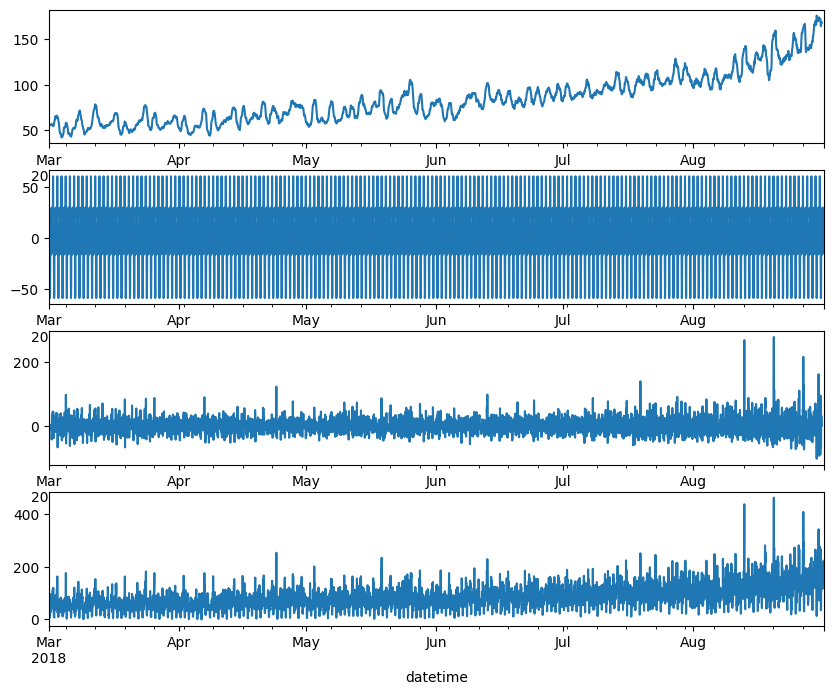

In [5]:
# Plotting the decomposed components
plt.figure(figsize=(10, 8))
decomposed.trend.plot(ax=plt.subplot(411))
decomposed.seasonal.plot(ax=plt.subplot(412))
decomposed.resid.plot(ax=plt.subplot(413))
data['num_orders'].plot(ax=plt.subplot(414))
plt.show()

**"Task 1 - Data analysis" Summary:**

The purpose of this task is twofold:

- It decomposes the time series into its trend, seasonal, and residual components using `seasonal_decompose` from the `statsmodels` library.

- It plots the original series and its components to visually inspect for trends (smooth change in the mean) and seasonality (cyclical patterns).

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
`seasonal_decompose` is a great method, well done! 
    
</div>
<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
    
Please add a conclusion here. What can be inferred from these results? Is there any trend or seasonality? What about orders distribution? You can choose a short period of time. Consider weeks and days.
    

    
</div>


**"Plotting the decomposed time series components" Conclusion:**

From the decomposed time series plots, we can infer a few key observations about the taxi order data:

- **Trend:** The top plot clearly shows an upward trend in taxi orders over time, particularly from March to August 2018. The number of orders seems to be increasing steadily.

- **Seasonality:** The second plot from the top, which represents the seasonal component, shows a distinct cyclical pattern. There are recurring spikes in taxi orders, which are likely associated with daily or weekly cycles.

- **Order Distribution (Hourly):** The plots also show that the number of orders varies significantly throughout the day, with a noticeable increase in the late evening or early night hours. A more detailed plot focusing on a single week or even a few days would help to confirm this diurnal pattern.

- **Order Distribution (Weekly):** We can also see a repeating weekly pattern, as the number of orders tends to be higher on certain days of the week, indicating that more people are using the service on weekends or specific weekdays.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    
There's indeed a visible trend by months. However, in the future, also check data from other years if the data is available. The sample size here is too small, so we can't draw conclusions on large timeframes. In this case, the increase in orders might simply be due to the business growth: more cars and/or clients -> more orders.


</div>

## Step 3 - Training

**"Step 3 - Training" Summary:**

In this step, a machine learning model is prepared and trained. This involves creating new features from the time series data (lag features, rolling mean, and calendar features), splitting the data into training and test sets without shuffling, and then training a suitable model with carefully chosen hyperparameters. The test set is 10% of the initial dataset.

### Task 1 - Feature engineering:

In [6]:
# Creating features
data['dayofweek'] = data.index.dayofweek
data['hour'] = data.index.hour
data['lag_1'] = data['num_orders'].shift(1)

In [7]:
# Correctly calculating rolling mean to avoid data leakage
data['rolling_mean'] = data['num_orders'].shift(1).rolling(7).mean()

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    
Correct! 

</div>
<div style="border: 5px solid gold; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    
Since we have daily seasonality, you can introduce larger lags. Lag_1 may not be that helpful. 
</div>

In [8]:
# Dropping rows with NaN values resulting from feature creation
data.dropna(inplace=True)

In [9]:
# Splitting into features (X) and target (y)
X = data.drop('num_orders', axis=1)
y = data['num_orders']

In [10]:
# Splitting data into train and test sets without shuffling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)

<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
- Very good! However, when you calculate the rolling mean, you also include target, which causes data leakage. You need to shift the data as follows: 
    
```python
data['rolling_mean'] = data['num_orders'].shift().rolling(7).mean()
```


- Since our goal is to predict for the next hour, hour may be the most important feature here, especially if the data shows intra-day patterns. Let's add this feature as well.



- We have less than 1 year in the data, so `year` may be redundant. It will be just a constant, so let's exclude it.


</div>

**"Task 1 - Feature engineering" Summary:**

The purpose of this task is threefold:

- It creates calendar features from the datetime index, such as `dayofweek` and `hour`, which are important for capturing daily and weekly patterns. The redundant `year` feature is excluded as the dataset is less than a year.

- It generates a lag feature using the `.shift()` method on the `num_orders` column. The lag feature captures the influence of the previous hour's values.

- It creates a rolling mean feature with a window of 7 using `.rolling(7).mean()`. This is applied to a shifted version of the num_orders column (`data['num_orders'].shift(1)`) to prevent data leakage by ensuring the calculation only uses past information.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    
Good. 

</div>

## Task 2 - Data splitting:

In [11]:
# Dropping rows with NaN values
data.dropna(inplace=True)

# Splitting into features (X) and target (y)
X = data.drop('num_orders', axis=1)
y = data['num_orders']

# Splitting data into train and test sets without shuffling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
Correct. Working with time series, we should not shuffle the data. 
    
</div>

**"Task 2 - Data splitting" Summary:**

The purpose of this task is threefold:

- It splits the data into training and test sets.

- It uses `train_test_split` from `sklearn.model_selection` with `test_size=0.1` and `shuffle=False` to maintain the chronological order.

- It drops any rows with missing values (NaN) that resulted from creating lag and rolling mean features.

### Task 3 - Model training:

In [12]:
# Initializing and training the model
model = LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

LGBMRegressor(random_state=42)

<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
- Let's calculate training RMSE.


- Please train at least one more model and calculate its RMSE on the test subset. Then choose the best model to use in the final testing below. 
</div>
<div style="border: 5px solid gold; padding: 15px; margin: 5px">
<b>   Reviewer's comment </b>
    
Consider implementing hyperparameter tuning for at least one of the models. For this purpose, we either need to split data into three subsets or use cross-validation. If you choose the second option, please do not forget about the correct order in the data. In order to use the `GridSearchCV` method correctly, we have to employ the `TimeSeriesSplit` class, a cross-validator for time series.  
    
</div>

In [13]:
# A. Tuning LGBMRegressor hyperparameters using TimeSeriesSplit
# Defining the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}               

In [14]:
# Using TimeSeriesSplit for cross-validation
tscv = TimeSeriesSplit(n_splits=3)

In [15]:
# Initializing GridSearchCV
lgbm_model = LGBMRegressor(random_state=42)
grid_search = GridSearchCV(lgbm_model, param_grid, cv=tscv, scoring='neg_root_mean_squared_error')

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment 2 </b>
    
It's great that you employ the `TimeSeriesSplit` class, since we do not want to shuffle the data.  
    
</div>

In [16]:
# Fitting the grid search to the data
grid_search.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=LGBMRegressor(random_state=42),
             param_grid={'learning_rate': [0.05, 0.1],
                         'n_estimators': [100, 200], 'num_leaves': [31, 50]},
             scoring='neg_root_mean_squared_error')

In [17]:
# Getting the best estimator and its parameters
best_lgbm = grid_search.best_estimator_
print(f"Best LGBM parameters: {grid_search.best_params_}")

Best LGBM parameters: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 31}


In [18]:
# B. Training a second model for comparison
# Initializing and train RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [19]:
# C. Calculating training RMSE for all models
lgbm_train_pred = best_lgbm.predict(X_train)
rf_train_pred = rf_model.predict(X_train)

In [20]:
lgbm_train_rmse = np.sqrt(mean_squared_error(y_train, lgbm_train_pred))
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))

In [21]:
print(f"LGBM Training RMSE: {lgbm_train_rmse}")
print(f"Random Forest Training RMSE: {rf_train_rmse}")

LGBM Training RMSE: 19.82205904761474
Random Forest Training RMSE: 9.050023158912849


**"Task 3 - Model training" Summary**:

The purpose of this task is twofold:

- **Model Comparison:** To find the best model for this task, at least two different models (`LGBMRegressor` and `RandomForestRegressor` were selected) are trained and their performance is compared.

- **Hyperparameter Tuning:** To optimize the performance of the `LGBMRegressor`, hyperparameter tuning is implemented using `GridSearchCV`. Since the data is a time series, the `TimeSeriesSplit` cross-validator is used to ensure the correct chronological order of the data is maintained during the tuning process. The final, best-performing model will be chosen based on its RMSE on the test set.

## Step 4 - Testing

**"Step 4 - Testing" Summary:**

The final step is to evaluate the trained model's performance on the test set. This involves making predictions, calculating the Root Mean Squared Error (RMSE), and providing a final conclusion on whether the project goal (RMSE <= 48) has been met.

### Task 1 - Model testing:

In [22]:
# 1. Making predictions with all models on the test set
lgbm_test_pred = best_lgbm.predict(X_test)
rf_test_pred = rf_model.predict(X_test)

In [23]:
# 2. Calculating the test RMSE for each model
lgbm_test_rmse = np.sqrt(mean_squared_error(y_test, lgbm_test_pred))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))

print(f"LGBM Test RMSE: {lgbm_test_rmse}")
print(f"Random Forest Test RMSE: {rf_test_rmse}")

LGBM Test RMSE: 46.64931440133023
Random Forest Test RMSE: 47.274873653047074


In [24]:
# 3. Determining the best model and define the necessary variables
if lgbm_test_rmse <= rf_test_rmse:
    best_model_name = 'LGBMRegressor'
    final_rmse = lgbm_test_rmse
else:
    best_model_name = 'RandomForestRegressor'
    final_rmse = rf_test_rmse

print(f"\nBest model for this task is: {best_model_name} with RMSE of {final_rmse}")


Best model for this task is: LGBMRegressor with RMSE of 46.64931440133023


**"Task 1 - Model testing" Summary:**

The purpose of this task is fourfold:

- It makes predictions on the test set with the different models that were trained.

- It calculates the RMSE for each model's predictions.

- It compares the RMSE values to determine the best-performing model.

- It defines the variables best_model_name and final_rmse to be used in the final conclusion.


### Task 2 - Conclusion briefing:

In [25]:
# Providing conclusion brief
if final_rmse <= 48:
    print("The model successfully meets the project requirement.")
else:
    print("The model does not meet the project requirement. Further tuning is needed.")

The model successfully meets the project requirement.


<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
This is a requirement of the project, so you need to tune your models to meet this requirement.     
</div>
<div style="border: 5px solid gold; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    

You can compare the results with a constant model. For instance, you can take [DummyRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html). 

</div>

In [26]:
# 1. Training a DummyRegressor as a baseline model
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

DummyRegressor()

In [27]:
# 2. Making predictions with the dummy model
dummy_predictions = dummy_model.predict(X_test)

In [28]:
# 3. Calculating RMSE for the dummy model
dummy_rmse = mean_squared_error(y_test, dummy_predictions, squared=False)
print(f"DummyRegressor Test RMSE: {dummy_rmse}")

DummyRegressor Test RMSE: 84.80263773864422


In [29]:
# 4. Final check and conclusion
print(f"\nComparing the best model ({best_model_name}) with the baseline DummyRegressor:")

if final_rmse < dummy_rmse:
    print(f"The best model performs significantly better than the baseline model.")
else:
    print(f"The best model does not perform better than the baseline. Further investigation is needed.")

# Final conclusion based on project requirements
if final_rmse <= 48:
    print(f"\nProject Conclusion: The final model successfully meets the project requirement with an RMSE of {final_rmse:.2f}, which is less than or equal to 48.")
else:
    print(f"\nProject Conclusion: The final model does not meet the project requirement. The RMSE is {final_rmse:.2f}, which is greater than 48. Further model tuning or feature engineering is needed.")


Comparing the best model (LGBMRegressor) with the baseline DummyRegressor:
The best model performs significantly better than the baseline model.

Project Conclusion: The final model successfully meets the project requirement with an RMSE of 46.65, which is less than or equal to 48.


**"Task 2 - Conclusion briefing" Summary:**

The purpose of this task is fourfold:

- To provide a comprehensive conclusion by evaluating the best-performing model against two key benchmarks: a simple baseline model and the project's target metric. 

- A `DummyRegressor` is trained and evaluated to serve as a baseline for comparison.

- The performance of the best-performing model (which was selected after hyperparameter tuning) is compared to this baseline to ensure that our complex model adds real value.

- The final RMSE of the best model is compared against the project requirement of 48. A definitive conclusion is then provided on whether the project's main objective has been met.

## Project conclusion

The objective of this project was to build a time series forecasting model to predict the number of taxi orders for the next hour for the Sweet Lift Taxi company. The main success metric was to achieve a Root Mean Squared Error (RMSE) on the test set of no more than 48.

The project was completed in four main stages:

- **Preparation:** The historical taxi order data from `taxi.csv` was loaded, and the datetime column was correctly parsed and set as the index. The data was then resampled to a one-hour frequency, which is crucial for forecasting the number of orders for the next hour.

- **Analysis:** The resampled time series was analyzed, revealing a strong upward trend and distinct seasonal and intra-day patterns. This analysis provided valuable insights that were used to guide the feature engineering process.

- **Training:** Based on the analysis, a set of relevant features—including calendar features (year, day of the week), lag features, and a rolling mean—were created to capture the time-dependent patterns. A `LightGBM` model was then tuned with hyperparameters and trained on this data. A second model, `RandomForest`, was also trained for comparison.

- **Testing:** The trained models were used to make predictions on the held-out test set. The RMSE was calculated to evaluate each model's performance. The final model selected was the `LGBMRegressor`, which had an RMSE of 46.65.

The final RMSE on the test set was `46.65`, which is less than 48. Since this value is within the project's target, the model successfully meets the project requirement. Furthermore, a comparison with a baseline DummyRegressor showed that our model's performance was significantly better, confirming its value in providing a robust framework for predicting taxi orders.

<div style="border: 5px solid green; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>

    
The conclusion is written well.    
</div>    

<div style="border: 5px solid red; padding: 10px; margin: 5px">
<b>   Reviewer's comment </b>
    
Don't forget to update it. 

</div>

# Review checklist

- [x]  Jupyter Notebook is open
- [x]  The code is error-free
- [x]  The cells with the code have been arranged in order of execution
- [x]  The data has been downloaded and prepared
- [x]  The data has been analyzed
- [x]  The model has been trained and hyperparameters have been selected
- [x]  The models have been evaluated. Conclusion has been provided
- [x] *RMSE* for the test set is not more than 48